# Bitcoin Sentiment vs Trader Performance — EDA

This notebook performs exploratory data analysis on the merged dataset combining:
- **Historical trade data** (from `historical_data.csv`)
- **Fear & Greed sentiment index** (from `fear_greed_index.csv`)

We analyse trade volumes, PnL distributions, sentiment breakdowns, and trading activity across coins and directions.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load Merged Data

In [2]:
ROOT = "/home/yash/Desktop/Projects/primetrade-ai"
df = pd.read_csv(f"{ROOT}/data/merged_data.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['trade_date'].min()} to {df['trade_date'].max()}")
df.head(3)


Shape: (211218, 20)
Columns: ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'trade_date', 'date', 'value', 'classification']
Date range: 2023-05-01 to 2025-05-01


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,trade_date,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,2024-12-02,80.0,Extreme Greed


## 3. Sentiment Distribution

A count of trades per Fear & Greed classification category.

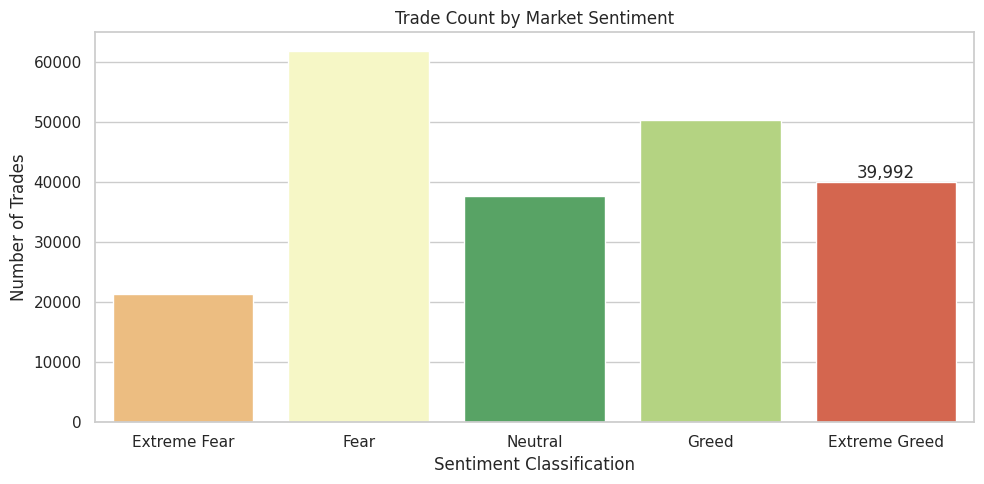

In [3]:
sentiment_order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="classification", order=sentiment_order,
                   palette="RdYlGn", hue="classification", legend=False)
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.title("Trade Count by Market Sentiment")
plt.xlabel("Sentiment Classification")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.savefig(f"{ROOT}/outputs/charts/sentiment_distribution.png", dpi=150)
plt.show()


## 4. PnL Distribution (Non-Zero)

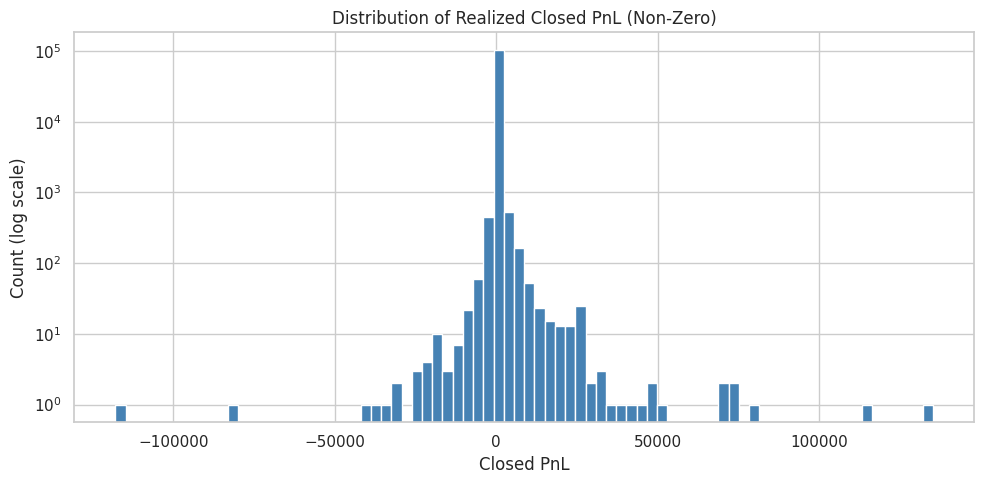

In [4]:
non_zero = df[df["closed_pnl"] != 0]

plt.figure(figsize=(10, 5))
plt.hist(non_zero["closed_pnl"], bins=80, color="steelblue", edgecolor="white")
plt.yscale("log")
plt.title("Distribution of Realized Closed PnL (Non-Zero)")
plt.xlabel("Closed PnL")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.savefig(f"{ROOT}/outputs/charts/pnl_distribution.png", dpi=150)
plt.show()


## 5. Daily Trade Volume Over Time

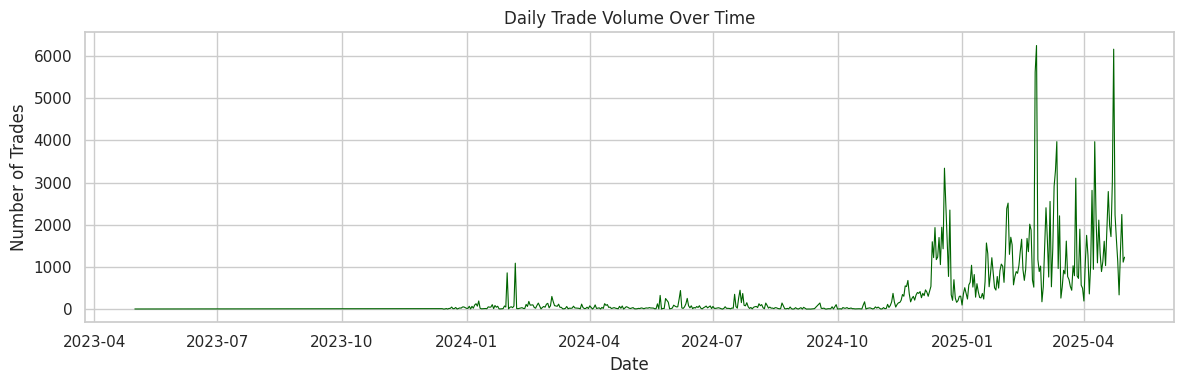

In [5]:
daily_volume = df.groupby("trade_date").size().reset_index(name="trade_count")

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(daily_volume["trade_date"]), daily_volume["trade_count"],
         color="darkgreen", linewidth=0.8)
plt.title("Daily Trade Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Trades")
plt.tight_layout()
plt.savefig(f"{ROOT}/outputs/charts/daily_trade_volume.png", dpi=150)
plt.show()


## 6. Direction Breakdown

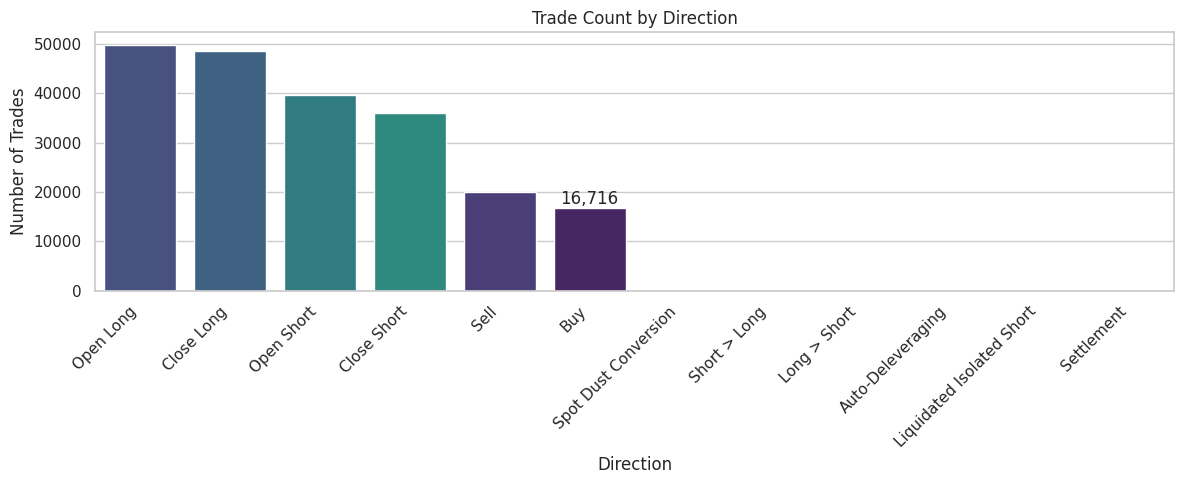

In [6]:
plt.figure(figsize=(12, 5))
order = df["direction"].value_counts().index
ax = sns.countplot(data=df, x="direction", order=order,
                   palette="viridis", hue="direction", legend=False)
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.title("Trade Count by Direction")
plt.xlabel("Direction")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{ROOT}/outputs/charts/direction_breakdown.png", dpi=150)
plt.show()


## 7. Top 15 Most Traded Coins

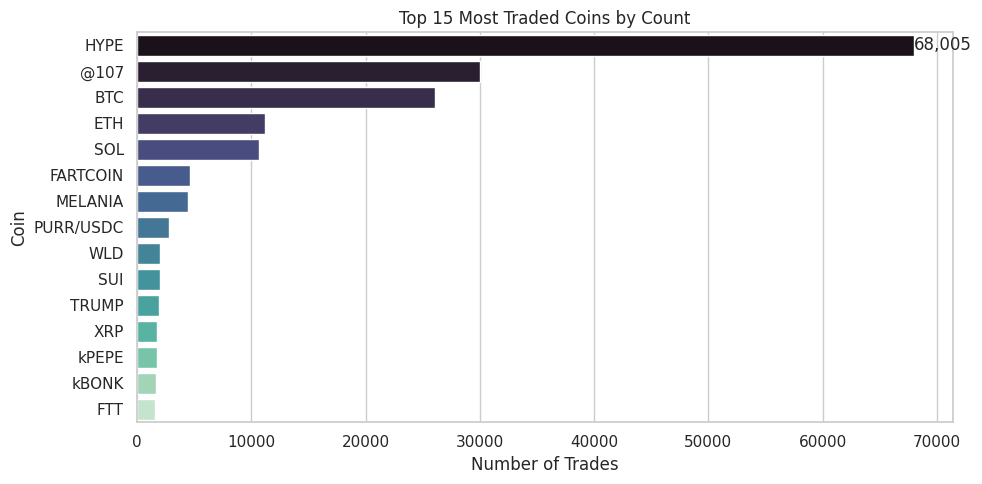

In [7]:
top_coins = df["coin"].value_counts().head(15)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=top_coins.values, y=top_coins.index, palette="mako", hue=top_coins.index, legend=False)
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.title("Top 15 Most Traded Coins by Count")
plt.xlabel("Number of Trades")
plt.ylabel("Coin")
plt.tight_layout()
plt.savefig(f"{ROOT}/outputs/charts/top_coins.png", dpi=150)
plt.show()


## 8. Exclusion Note for Future Analysis

> **Note:** 'Spot Dust Conversion' and 'Settlement' directions are administrative events, not active trades. They will be excluded from all subsequent win rate, PnL, and long/short strategy analysis.